# Week 4 · Notebook 1 — Anatomy of a Genetic Algorithm and the Mathematics of Selection

**Goals**
- Write the generational loop of a genetic algorithm (GA) as a composition of well-defined mechanisms:
  representation, evaluation, parent selection, variation, replacement, elitism.
- Implement six parent-selection operators — roulette wheel, stochastic universal sampling (SUS), linear ranking,
  $k$-tournament, truncation, Boltzmann — and validate their selection probabilities against closed forms.
- **Prove** that SUS has zero bias and minimal spread (Baker 1987) and check it on $10^4$ draws.
- Derive **takeover times** (Goldberg & Deb 1991) for tournament, truncation and proportional selection, and compare
  the deterministic theory with stochastic simulation over many seeds.
- Measure **selection intensity** against its Gaussian closed forms, and the **loss of diversity** per generation.
- Compare selection schemes, elitism and steady-state vs generational replacement inside a full GA on a planted
  MAX-3SAT instance with a known optimum, at an equal evaluation budget.

**Prerequisites:** Week 1 (landscapes, local search), elementary probability (binomial, Poisson, order statistics).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from scipy import integrate, stats
from utils import PALETTE

## 1. The generational loop

A genetic algorithm (Holland 1975, *Adaptation in Natural and Artificial Systems*; popularised by Goldberg 1989,
*Genetic Algorithms in Search, Optimization, and Machine Learning*; De Jong's 1975 thesis gave the first systematic
function-optimisation study) is a **population-based** stochastic search. Stripped of the biological vocabulary, it
is defined by five mechanisms:

| Mechanism | Precise meaning | Typical choices |
|---|---|---|
| Representation | encoding $g \in G$ of a candidate and decoder $G \to S$ | bit strings, real vectors, permutations |
| Parent selection | random map from a population (multiset) and its fitness values to a multiset of parents | roulette, SUS, ranking, tournament |
| Variation | stochastic kernels $G\times G \to G$ (crossover) and $G \to G$ (mutation) | one-point, uniform, SBX; bit-flip, Gaussian |
| Replacement (survivor selection) | how parents and offspring are merged into the next population | generational, steady-state, $(\mu+\lambda)$ |
| Elitism | guarantee that the best-so-far survives | copy the best $e$ individuals |

```text
P_0 <- N random genotypes; evaluate f on P_0
for t = 0, 1, 2, ... until the budget of evaluations is exhausted:
    M   <- select(P_t, f, N)                 # mating pool (parent selection)
    O   <- []                                # offspring
    for consecutive pairs (a, b) in M:
        (c1, c2) <- crossover(a, b) with probability p_c, else (a, b)
        O += [mutate(c1), mutate(c2)]
    evaluate f on O                          # N evaluations per generation
    P_{t+1} <- replace(P_t, O)               # generational: P_{t+1} = O
    if elitism: put the best of P_t back in place of the worst of P_{t+1}
```

Selection is the **only** mechanism that looks at fitness; variation is fitness-blind. All of the "search
direction" of a GA therefore comes from selection, and all of the novelty from variation. This notebook isolates
selection; Notebook 2 isolates variation.

Throughout, fitness $f$ is **maximised** (the GA convention), $n$ is the population size and $e_i$ the
**expected number of copies** of individual $i$ in the mating pool.

## 2. Selection operators

Each operator returns $m$ indices into a population with fitness vector $f \in \mathbb{R}^n$.

* **Roulette wheel / fitness-proportional** (Holland 1975): $m$ i.i.d. draws with $p_i = f_i / \sum_j f_j$
  (requires $f \ge 0$), so $e_i = m\,p_i$.
* **Stochastic universal sampling** (Baker 1987): lay the expected counts $e_i$ end to end on $[0, m)$ and place
  $m$ equally spaced pointers $u, u+1, \dots, u+m-1$ with a *single* $u \sim U[0,1)$.
* **Linear ranking** (Baker 1985; Grefenstette & Baker 1989): sort ascending, rank $r = 0$ (worst) $\dots n-1$
  (best), $p_r = \frac{1}{n}\big(\eta^- + (\eta^+ - \eta^-)\tfrac{r}{n-1}\big)$ with $\eta^+ = s \in [1,2]$ and
  $\eta^- = 2 - s$; $s$ is the expected number of copies of the best.
* **$k$-tournament** (Brindle 1981; Goldberg & Deb 1991): draw $k$ individuals uniformly with replacement, keep the
  best. If fitnesses are distinct and $i$ is the $i$-th worst ($i = 1..n$),
  $P(\text{select } i) = \big(i^k - (i-1)^k\big)/n^k$ — the winner has rank $\le i$ iff all $k$ draws have rank $\le i$.
* **Truncation** (Mühlenbein & Schlierkamp-Voosen 1993, breeder GA): uniform among the best $\lceil \tau n\rceil$.
* **Boltzmann** (de la Maza & Tidor 1993; the selection rule inside simulated annealing and replicator dynamics):
  $p_i \propto \exp(f_i / T)$; temperature $T$ controls pressure.

Only roulette and Boltzmann depend on the *values* of $f$; ranking, tournament and truncation depend only on the
*order* — they are invariant under any strictly increasing transformation of $f$, which is exactly the invariance
we want when the scale of the objective is arbitrary (a validation loss, a tour length).

In [2]:
def roulette(f, m, rng):
    """Fitness-proportional selection: m i.i.d. draws with p_i = f_i / sum f (f >= 0)."""
    c = np.cumsum(f, dtype=float)
    return np.searchsorted(c, rng.random(m) * c[-1], side="right")


def sus(weights, m, rng):
    """Stochastic universal sampling (Baker 1987): one spin, m equally spaced pointers."""
    c = np.cumsum(weights, dtype=float)
    c = c / c[-1] * m
    c[-1] = m                                    # guard against round-off: pointers are < m
    ptr = rng.random() + np.arange(m)
    return np.searchsorted(c, ptr, side="right")


def linear_rank_probs(f, s=2.0):
    """Baker's linear ranking probabilities, s = expected copies of the best (1 <= s <= 2)."""
    n = len(f)
    r = np.empty(n)
    r[np.argsort(f, kind="stable")] = np.arange(n)
    return ((2 - s) + (2 * s - 2) * r / (n - 1)) / n


def linear_ranking(f, m, rng, s=2.0):
    return sus(linear_rank_probs(f, s), m, rng)


def tournament(f, m, rng, k=2):
    idx = rng.integers(0, len(f), size=(m, k))
    return idx[np.arange(m), np.argmax(f[idx], axis=1)]


def truncation(f, m, rng, tau=0.5):
    top = np.argsort(f)[::-1][: int(np.ceil(tau * len(f)))]
    return top[rng.integers(0, len(top), m)]


def boltzmann(f, m, rng, T=1.0):
    w = np.exp((f - f.max()) / T)                # shift for numerical stability
    return roulette(w, m, rng)

### 2.1 Validation: empirical selection frequencies vs closed forms

On a fixed population of $n = 20$ individuals with distinct fitnesses we draw $N = 4\times 10^5$ parents per
operator and compare frequencies with the analytic probabilities. With $N$ draws each frequency has standard error
$\sqrt{p(1-p)/N}$; we require every deviation to be below $5$ standard errors. For tournament selection the closed
form $(i^k-(i-1)^k)/n^k$ is derived independently of the code (which just takes an `argmax`), so this is a genuine
test of the implementation.

In [3]:
n = 20
f_pop = np.sort(rng.uniform(1, 10, n))          # ascending: index i has rank i (0 = worst)
N = 400_000
i1 = np.arange(1, n + 1)
analytic = {
    "roulette": f_pop / f_pop.sum(),
    "linear ranking s=2": ((0.0) + 2.0 * np.arange(n) / (n - 1)) / n,
    "tournament k=2": (i1**2 - (i1 - 1) ** 2) / n**2,
    "tournament k=4": (i1**4 - (i1 - 1) ** 4) / n**4,
    "truncation tau=0.25": np.r_[np.zeros(15), np.full(5, 0.2)],
    "Boltzmann T=2": np.exp(f_pop / 2) / np.exp(f_pop / 2).sum(),
}
samplers = {
    "roulette": lambda: roulette(f_pop, N, rng),
    "linear ranking s=2": lambda: np.concatenate([linear_ranking(f_pop, 1000, rng) for _ in range(N // 1000)]),
    "tournament k=2": lambda: tournament(f_pop, N, rng, 2),
    "tournament k=4": lambda: tournament(f_pop, N, rng, 4),
    "truncation tau=0.25": lambda: truncation(f_pop, N, rng, 0.25),
    "Boltzmann T=2": lambda: boltzmann(f_pop, N, rng, 2.0),
}
emp = {}
for name, draw in samplers.items():
    freq = np.bincount(draw(), minlength=n) / N
    emp[name] = freq
    p = analytic[name]
    z = np.abs(freq - p) / np.sqrt(np.maximum(p * (1 - p), 1e-12) / N)
    check_true(np.all(z[p > 0] < 5) and np.all(freq[p == 0] == 0),
               f"{name:22s} frequencies match closed form (max |z| = {z[p > 0].max():.2f})")

[PASS] roulette               frequencies match closed form (max |z| = 2.28)
[PASS] linear ranking s=2     frequencies match closed form (max |z| = 0.19)
[PASS] tournament k=2         frequencies match closed form (max |z| = 2.87)


[PASS] tournament k=4         frequencies match closed form (max |z| = 1.75)
[PASS] truncation tau=0.25    frequencies match closed form (max |z| = 1.65)
[PASS] Boltzmann T=2          frequencies match closed form (max |z| = 1.94)


SUS is also listed under "linear ranking": ranking only defines the probabilities, and the sampling algorithm
(roulette or SUS) is a separate choice. Note the $n$ repeated SUS spins give *correlated* draws within a spin, which
is why we compare only frequencies above.

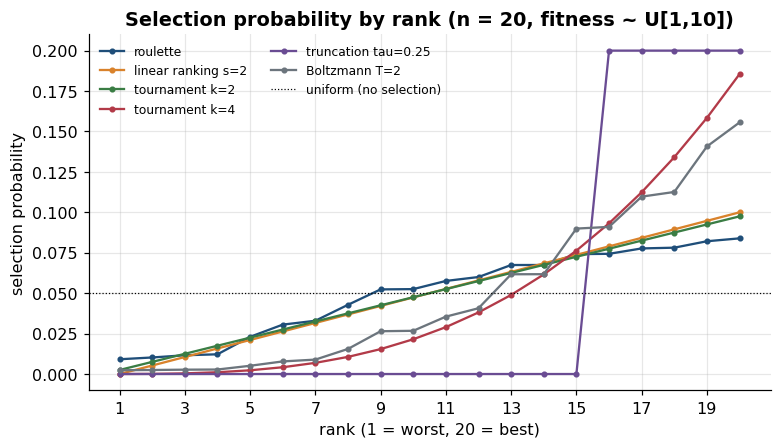

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for name, p in analytic.items():
    ax.plot(np.arange(1, n + 1), p, marker="o", ms=3, label=name)
ax.axhline(1 / n, color="k", lw=0.8, ls=":", label="uniform (no selection)")
ax.set(xlabel="rank (1 = worst, 20 = best)", ylabel="selection probability",
       title="Selection probability by rank (n = 20, fitness ~ U[1,10])")
ax.set_xticks(np.arange(1, n + 1, 2))
ax.legend(fontsize=8, ncol=2)
savefig("w4_selection_probabilities.png"); plt.show()

### 2.2 SUS: zero bias and minimal spread

Baker (1987) called a sampling algorithm **unbiased** if the expected number of copies $E[c_i]$ equals $e_i$, and
defined its **spread** as the range of values $c_i$ can take. The minimal possible spread for an unbiased sampler
is $\lbrace \lfloor e_i \rfloor, \lceil e_i \rceil\rbrace$.

**Theorem (Baker 1987).** SUS is unbiased and has minimal spread.

*Proof.* Let $C_i = \sum_{j \le i} e_j$ and $I_i = [C_{i-1}, C_i)$, an interval of length $e_i$. Individual $i$ is
selected once for every pointer $u + j$ ($j = 0..m-1$) in $I_i$. (i) *Spread:* the pointers form a lattice of
spacing 1, and a half-open interval of length $e$ contains either $\lfloor e\rfloor$ or $\lceil e\rceil$ points of
any unit-spaced lattice. (ii) *Bias:* the number of lattice points of $u + \mathbb{Z}$ in $I_i$ is
$\sum_{z \in \mathbb{Z}} \mathbf{1}[u + z \in I_i]$; taking expectation over $u \sim U[0,1)$ gives
$\sum_z |I_i \cap [z, z+1)| = |I_i| = e_i$. $\square$

Roulette is also unbiased but its counts are $\mathrm{Binomial}(m, e_i/m)$ with spread $\lbrace 0, \dots, m\rbrace$
and variance $e_i(1 - e_i/m)$; SUS has variance $\varphi_i(1-\varphi_i)$ with $\varphi_i = e_i - \lfloor e_i\rfloor$,
the smallest variance of any integer random variable with mean $e_i$.

In [5]:
m_sus, reps = 20, 10_000
e = f_pop / f_pop.sum() * m_sus
counts_sus = np.array([np.bincount(sus(f_pop, m_sus, rng), minlength=n) for _ in range(reps)])
counts_rw = np.array([np.bincount(roulette(f_pop, m_sus, rng), minlength=n) for _ in range(reps)])
check_true(np.all((counts_sus == np.floor(e)) | (counts_sus == np.ceil(e))),
           "SUS: every count in {floor(e_i), ceil(e_i)} over 10,000 spins")
se = counts_sus.std(0) / np.sqrt(reps) + 1e-12
check_true(np.all(np.abs(counts_sus.mean(0) - e) < 5 * np.maximum(se, 0.5 / np.sqrt(reps))), "SUS: unbiased, E[c_i] = e_i")
phi = e - np.floor(e)
check_close(np.abs(counts_sus.var(0) - phi * (1 - phi)).max(), 0.0, "SUS: max |Var(c_i) - phi(1-phi)|", atol=0.02)
check_close(np.abs(counts_rw.var(0) - e * (1 - e / m_sus)).max(), 0.0, "roulette: max |Var(c_i) - e(1-e/m)|", atol=0.1)
print(f"mean variance of counts: roulette {counts_rw.var(0).mean():.3f}  vs  SUS {counts_sus.var(0).mean():.3f}")

[PASS] SUS: every count in {floor(e_i), ceil(e_i)} over 10,000 spins
[PASS] SUS: unbiased, E[c_i] = e_i
[PASS] SUS: max |Var(c_i) - phi(1-phi)|: got 0.005065, expected 0.0
[PASS] roulette: max |Var(c_i) - e(1-e/m)|: got 0.046003, expected 0.0
mean variance of counts: roulette 0.930  vs  SUS 0.190


## 3. Selection intensity

Pressure can be measured on a standard-normal fitness distribution by the **selection intensity**
$I = (\bar f_{\text{sel}} - \bar f)/\sigma_f$ (Mühlenbein & Schlierkamp-Voosen 1993, borrowing the breeder's
equation $R = h^2 I \sigma$ from quantitative genetics; Blickle & Thiele 1995 for the comparison of schemes).
In the large-population limit:

* truncation with fraction $\tau$: $I = \varphi(z_\tau)/\tau$ with $z_\tau = \Phi^{-1}(1-\tau)$ (mean of a
  truncated normal);
* $k$-tournament: $I_k = E[\max(Z_1..Z_k)] = \int x\,k\,\varphi(x)\Phi(x)^{k-1}dx$, with the closed forms
  $I_2 = 1/\sqrt{\pi}$ and $I_3 = 3/(2\sqrt{\pi})$;
* linear ranking: $I = (s-1)/\sqrt{\pi}$ (a rank-$r$ individual is picked with probability linear in its quantile,
  and $E[Z\,\Phi(Z)] = 1/(2\sqrt{\pi})$).

We check these with a population of $2\times 10^5$ standard normal fitnesses, using `scipy.integrate.quad` as an
independent reference for the integrals.

In [6]:
fz = rng.standard_normal(200_000)
M = 200_000
def intensity(idx):
    return (fz[idx].mean() - fz.mean()) / fz.std()

Ik = lambda k: integrate.quad(lambda x: x * k * stats.norm.pdf(x) * stats.norm.cdf(x) ** (k - 1), -12, 12)[0]
check_close(Ik(2), 1 / np.sqrt(np.pi), "quad: I_2 = 1/sqrt(pi)", atol=1e-8)
check_close(Ik(3), 3 / (2 * np.sqrt(np.pi)), "quad: I_3 = 3/(2 sqrt(pi))", atol=1e-8)
rows = []
for k in (2, 3, 5, 10):
    rows.append((f"tournament k={k}", intensity(tournament(fz, M, rng, k)), Ik(k)))
for tau in (0.5, 0.2, 0.1):
    zt = stats.norm.ppf(1 - tau)
    rows.append((f"truncation tau={tau}", intensity(truncation(fz, M, rng, tau)), stats.norm.pdf(zt) / tau))
for s in (1.5, 2.0):
    rows.append((f"linear ranking s={s}", intensity(linear_ranking(fz, M, rng, s)), (s - 1) / np.sqrt(np.pi)))
print(f"{'operator':22s} {'simulated':>10s} {'theory':>8s}")
for name, sim, th in rows:
    print(f"{name:22s} {sim:10.4f} {th:8.4f}")
check_true(all(abs(sim - th) < 0.01 for _, sim, th in rows), "all selection intensities within 0.01 of theory")

[PASS] quad: I_2 = 1/sqrt(pi): got 0.56419, expected 0.56419
[PASS] quad: I_3 = 3/(2 sqrt(pi)): got 0.846284, expected 0.846284


operator                simulated   theory
tournament k=2             0.5634   0.5642
tournament k=3             0.8429   0.8463
tournament k=5             1.1630   1.1630
tournament k=10            1.5407   1.5388
truncation tau=0.5         0.7979   0.7979
truncation tau=0.2         1.3981   1.3998
truncation tau=0.1         1.7536   1.7550
linear ranking s=1.5       0.2827   0.2821
linear ranking s=2.0       0.5638   0.5642
[PASS] all selection intensities within 0.01 of theory


Tournament size and truncation fraction are therefore interchangeable knobs on one scale: $k = 2$ ($I \approx 0.56$)
is milder than truncation with $\tau = 0.5$ ($I \approx 0.80$), and $k = 5$ ($I \approx 1.16$) sits between
$\tau = 0.5$ and $\tau = 0.2$ ($I \approx 1.40$).

## 4. Takeover time

**Definition (Goldberg & Deb 1991).** Start with a single copy of the best individual, apply selection only (no
variation), and count generations until the population consists entirely of copies of it. Short takeover time =
high pressure = fast loss of diversity.

Let $P_t$ be the proportion of best copies and $Q_t = 1 - P_t$. In the deterministic (infinite-population)
approximation:

* **$k$-tournament**: a tournament returns a non-best individual iff all $k$ entrants are non-best, so
  $Q_{t+1} = Q_t^k$ and $Q_t = Q_0^{k^t}$. With $Q_0 = 1 - 1/n$ and the takeover criterion $Q_t \le 1/n$:
  $k^t \ge \ln n / (-\ln(1-1/n)) \approx n\ln n$, hence

$$t^{\ast}_{\text{tour}} \approx \frac{\ln n + \ln\ln n}{\ln k}.$$

* **Truncation** with fraction $\tau$: $P_{t+1} = \min(1, P_t/\tau)$, so $P_t = \tau^{-t}/n$ and
  $t^{\ast}_{\text{trunc}} = \lceil \ln n / \ln(1/\tau)\rceil$ (for $\tau = 1/2$ and $n = 2^j$: exactly $j$ generations,
  because once $P_t \ge \tau$ the whole truncated set consists of copies of the best).
* **Proportional**, best fitness $r$ times the rest: $P_{t+1} = rP_t/(rP_t + Q_t)$, i.e. the odds $P_t/Q_t$ are
  multiplied by $r$ each generation; from odds $1/(n-1)$ to odds $n-1$:

$$t^{\ast}_{\text{prop}} \approx \frac{2\ln(n-1)}{\ln r}.$$

The logarithmic takeover of rank-based schemes versus the dependence on $r$ for proportional selection is the
formal version of the classical observation that proportional selection loses pressure when fitness values are
close (late in a run) and is too strong when one "super-individual" dominates (early in a run).

In a finite population the best can also be **lost by sampling** (drift). We simulate with the actual operators,
report the median takeover among runs in which the best fixated, and the loss rate.

In [7]:
def takeover(select, n, rng, r=2.0, max_gen=500):
    """Generations until all individuals are copies of the best; None if the best is lost."""
    fit = np.ones(n); fit[0] = r
    for t in range(1, max_gen + 1):
        fit = fit[select(fit, n, rng)]
        nb = np.count_nonzero(fit == r)
        if nb == 0:
            return None
        if nb == n:
            return t
    return None

schemes = {
    "tournament k=2": (lambda f, m, g: tournament(f, m, g, 2),
                       lambda n: (np.log(n) + np.log(np.log(n))) / np.log(2)),
    "tournament k=4": (lambda f, m, g: tournament(f, m, g, 4),
                       lambda n: (np.log(n) + np.log(np.log(n))) / np.log(4)),
    "truncation tau=0.5": (lambda f, m, g: truncation(f, m, g, 0.5),
                           lambda n: np.ceil(np.log(n) / np.log(2))),
    "roulette r=2": (roulette, lambda n: 2 * np.log(n - 1) / np.log(2)),
    "SUS r=2": (sus, lambda n: 2 * np.log(n - 1) / np.log(2)),
}
ns = np.array([32, 64, 128, 256, 512, 1024, 2048])
seeds = 40
res = {}
for name, (sel, theory) in schemes.items():
    med, q1, q3, loss = [], [], [], []
    for n_ in ns:
        g = np.random.default_rng(int(n_))
        out = [takeover(sel, n_, g) for _ in range(seeds)]
        ok = np.array([o for o in out if o is not None])
        med.append(np.median(ok)); q1.append(np.percentile(ok, 25)); q3.append(np.percentile(ok, 75))
        loss.append(1 - len(ok) / seeds)
    res[name] = (np.array(med), np.array(q1), np.array(q3), np.array(loss), theory(ns))
print(f"{'scheme':20s} " + " ".join(f"{n_:>6d}" for n_ in ns))
for name, (med, q1, q3, loss, th) in res.items():
    print(f"{name:20s} " + " ".join(f"{m_:6.1f}" for m_ in med) + "   (sim median)")
    print(f"{'':20s} " + " ".join(f"{t_:6.1f}" for t_ in th) + "   (theory)")
    print(f"{'':20s} " + " ".join(f"{l_:6.2f}" for l_ in loss) + "   (fraction of runs losing the best)")

scheme                   32     64    128    256    512   1024   2048
tournament k=2          7.0    9.0    9.0   11.0   12.0   13.0   14.0   (sim median)
                        6.8    8.1    9.3   10.5   11.6   12.8   13.9   (theory)
                       0.20   0.28   0.12   0.18   0.30   0.22   0.18   (fraction of runs losing the best)
tournament k=4          4.0    5.0    5.0    6.0    6.5    7.0    7.0   (sim median)
                        3.4    4.0    4.6    5.2    5.8    6.4    7.0   (theory)
                       0.00   0.00   0.03   0.00   0.00   0.00   0.00   (fraction of runs losing the best)
truncation tau=0.5      5.0    6.0    7.0    8.0    9.5   11.0   11.0   (sim median)
                        5.0    6.0    7.0    8.0    9.0   10.0   11.0   (theory)
                       0.20   0.22   0.20   0.30   0.35   0.22   0.22   (fraction of runs losing the best)
roulette r=2           11.0   14.0   14.0   15.0   19.0   21.0   23.0   (sim median)
                        9.

The deterministic theory is an approximation (it ignores sampling noise and the discreteness of the last few
copies), so we validate it within $\pm 2$ generations for tournaments, $\pm 1$ for truncation (whose recursion is
exact up to sampling noise) and $\pm 3$ for SUS with $r = 2$, over a 64-fold range of $n$.

In [8]:
for name, tol in (("tournament k=2", 2.0), ("tournament k=4", 2.0), ("truncation tau=0.5", 1.0)):
    med, _, _, _, th = res[name]
    check_true(np.all(np.abs(med - th) <= tol), f"{name}: simulated median within {tol:.0f} generation(s) of theory")
med_s = res["SUS r=2"][0]
check_true(np.all(np.abs(med_s - res["SUS r=2"][4]) <= 3.0), "SUS r=2: within 3 generations of 2 ln(n-1)/ln 2")
check_true(res["roulette r=2"][3].mean() > res["SUS r=2"][3].mean(),
           "roulette loses the best individual more often than SUS (drift from sampling variance)")

[PASS] tournament k=2: simulated median within 2 generation(s) of theory
[PASS] tournament k=4: simulated median within 2 generation(s) of theory
[PASS] truncation tau=0.5: simulated median within 1 generation(s) of theory
[PASS] SUS r=2: within 3 generations of 2 ln(n-1)/ln 2
[PASS] roulette loses the best individual more often than SUS (drift from sampling variance)


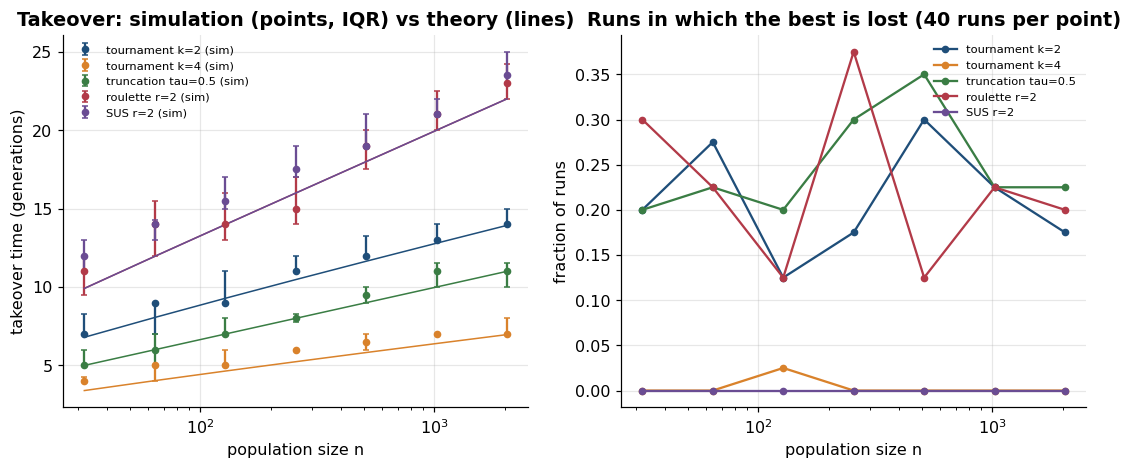

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for (name, (med, q1, q3, loss, th)), col in zip(res.items(), PALETTE.values()):
    ax[0].errorbar(ns, med, yerr=[med - q1, q3 - med], fmt="o", color=col, ms=4, capsize=2, label=f"{name} (sim)")
    ax[0].plot(ns, th, "-", color=col, lw=1)
    ax[1].plot(ns, loss, "o-", color=col, ms=4, label=name)
ax[0].set(xscale="log", xlabel="population size n", ylabel="takeover time (generations)",
          title="Takeover: simulation (points, IQR) vs theory (lines)")
ax[0].legend(fontsize=7.5)
ax[1].set(xscale="log", xlabel="population size n", ylabel="fraction of runs",
          title="Runs in which the best is lost (40 runs per point)")
ax[1].legend(fontsize=7.5)
savefig("w4_takeover_time.png"); plt.show()

## 5. Loss of diversity in one generation

How many individuals receive no copy at all? For $k$-tournament in a large population, an individual at quantile
$x$ (fraction $x$ of the population is worse) is selected by each of the $n$ tournaments with probability
$\approx k x^{k-1}/n$, so its number of copies is approximately $\mathrm{Poisson}(k x^{k-1})$ and the expected fraction
never selected is

$$L_k = \int_0^1 e^{-k x^{k-1}}\,dx, \qquad L_2 = \frac{1-e^{-2}}{2} \approx 0.432.$$

(Blickle & Thiele 1995 define a related *deterministic* "loss of diversity" $k^{-1/(k-1)} - k^{-k/(k-1)}$ — the
selection-probability mass lost below the break-even quantile — which is $0.25$ for $k = 2$. Our $L_k$ also counts
the sampling losses, which dominate in practice.) Even with no selection pressure at all, i.i.d. sampling of $n$
parents loses a fraction $(1-1/n)^n \to e^{-1} \approx 0.368$; SUS with equal fitness loses nothing.

For **linear ranking with $s = 2$ sampled by SUS**, individual $r$ has $e_r = 2r/(n-1)$. The intervals of the
lower half have length $\lt 1$ and therefore hold at most one pointer each; the lower half carries total mass
$\sum_{r \lt n/2} e_r \approx n/4$, i.e. $\approx n/4$ pointers hitting $n/4$ distinct individuals, while every
upper-half individual ($e_r \ge 1$) is hit. So $\approx n/4$ of the $n/2$ lower-half individuals are lost:
a lost fraction of $1/4$, with almost no randomness.

In [10]:
n_big, gens = 5000, 20
fr = rng.permutation(n_big).astype(float)
def lost_fraction(select):
    return np.mean([1 - len(np.unique(select(fr, n_big, rng))) / n_big for _ in range(gens)])

L = {}
for k in (2, 3, 4, 8):
    L[f"tournament k={k}"] = (lost_fraction(lambda f, m, g: tournament(f, m, g, k)),
                              integrate.quad(lambda x: np.exp(-k * x ** (k - 1)), 0, 1)[0])
L["uniform (no pressure)"] = (lost_fraction(lambda f, m, g: g.integers(0, len(f), m)), np.exp(-1))
L["SUS, equal fitness"] = (lost_fraction(lambda f, m, g: sus(np.ones(len(f)), m, g)), 0.0)
L["linear ranking s=2 (SUS)"] = (lost_fraction(lambda f, m, g: linear_ranking(f, m, g, 2.0)), 0.25)
for name, (sim, th) in L.items():
    print(f"{name:26s} simulated {sim:.4f}   theory {th:.4f}")
check_close(L["tournament k=2"][1], (1 - np.exp(-2)) / 2, "quad: L_2 = (1-e^-2)/2", atol=1e-10)
check_true(all(abs(sim - th) < 0.01 for sim, th in L.values()), "lost fractions within 0.01 of theory")

tournament k=2             simulated 0.4319   theory 0.4323
tournament k=3             simulated 0.5048   theory 0.5043
tournament k=4             simulated 0.5608   theory 0.5612
tournament k=8             simulated 0.6947   theory 0.6950
uniform (no pressure)      simulated 0.3683   theory 0.3679
SUS, equal fitness         simulated 0.0000   theory 0.0000
linear ranking s=2 (SUS)   simulated 0.2489   theory 0.2500
[PASS] quad: L_2 = (1-e^-2)/2: got 0.432332, expected 0.432332
[PASS] lost fractions within 0.01 of theory


## 6. Selection inside a full GA: planted MAX-3SAT

To compare selection schemes in a complete algorithm we need a problem with a **known optimum**. A *planted*
3-SAT instance is generated by drawing a hidden assignment $x^{\ast}$ and keeping only random 3-clauses that
$x^{\ast}$ satisfies; the optimum of MAX-3SAT is then exactly $m$ (all clauses satisfied). We use $n_v = 100$
variables and $m = 426$ clauses (ratio $4.26$, near the satisfiability threshold of *uniform* random 3-SAT).

The GA: bit strings, population $N = 100$, uniform crossover ($p_c = 0.9$), bit-flip mutation with rate $1/L$,
generational replacement with 1-elitism, budget $B = 30{,}000$ evaluations, stop early at the optimum.
We also run two replacement variants with 2-tournament parent selection:

* **no elitism** — pure generational replacement;
* **steady-state** (Whitley's GENITOR 1989; Syswerda 1989): one offspring per step replaces the current worst
  individual if it is at least as good. Each step costs one evaluation, so the budget is identical.

**Diversity** is tracked as the mean pairwise Hamming distance divided by $L$, computed in $O(NL)$ with the
identity $\frac{1}{\binom N2}\sum_{i\lt j} d_H(x_i,x_j) = \sum_{\ell} \frac{2 c_\ell (N-c_\ell)}{N(N-1)}$,
where $c_\ell$ is the number of ones at locus $\ell$ (each locus contributes one unit to every pair that
disagrees on it). We validate the identity against brute force first.

In [11]:
def planted_3sat(nv, m, rng):
    """Random 3-clauses (signed 1-based literals) all satisfied by a hidden assignment x_star."""
    x_star = rng.random(nv) < 0.5
    out = []
    while len(out) < m:
        v = rng.choice(nv, 3, replace=False)
        sg = rng.choice([-1, 1], 3)
        if np.any(np.where(sg > 0, x_star[v], ~x_star[v])):
            out.append((v + 1) * sg)
    return np.array(out), x_star


def n_satisfied(X, cl):
    """Batched clause count: X is (N, nv) boolean; a literal is true iff x_var == (sign > 0)."""
    return ((X[:, np.abs(cl) - 1] == (cl > 0)).any(axis=2)).sum(axis=1)


def diversity(P):
    """Mean pairwise Hamming distance / L via the per-locus identity."""
    N, L = P.shape
    c = P.sum(0)
    return float((2 * c * (N - c)).sum() / (N * (N - 1)) / L)


Ptest = rng.random((30, 50)) < 0.3
brute = np.mean([np.sum(Ptest[i] != Ptest[j]) for i in range(30) for j in range(i + 1, 30)]) / 50
check_close(diversity(Ptest), brute, "diversity identity vs brute-force pairwise Hamming")

from utils import count_satisfied
cl, x_star = planted_3sat(100, 426, np.random.default_rng(2024))
check_true(count_satisfied(x_star, cl) == len(cl), "planted assignment satisfies all 426 clauses (utils.count_satisfied)")
Xr = rng.random((5, 100)) < 0.5
check_true(all(n_satisfied(Xr, cl)[i] == count_satisfied(Xr[i], cl) for i in range(5)),
           "batched clause counter agrees with utils.count_satisfied")

[PASS] diversity identity vs brute-force pairwise Hamming: got 0.428276, expected 0.428276
[PASS] planted assignment satisfies all 426 clauses (utils.count_satisfied)
[PASS] batched clause counter agrees with utils.count_satisfied


In [12]:
def ga_generational(fitness, L, select, rng, N=100, budget=30_000, pc=0.9, elitism=True, f_target=None):
    """Generational GA on bit strings with uniform crossover and 1/L bit-flip mutation (maximisation)."""
    P = rng.random((N, L)) < 0.5
    f = fitness(P); evals = N
    tr_e, tr_b, tr_d = [evals], [f.max()], [diversity(P)]
    while evals + N <= budget and tr_b[-1] < f_target:
        par = P[select(f.astype(float), N, rng)]
        a, b = par[0::2], par[1::2]
        swap = (rng.random((N // 2, L)) < 0.5) & (rng.random((N // 2, 1)) < pc)
        C = np.concatenate([np.where(swap, b, a), np.where(swap, a, b)])
        C ^= rng.random((N, L)) < 1.0 / L
        fc = fitness(C); evals += N
        if elitism and f.max() > fc.max():          # best parent replaces the worst child
            iw = np.argmin(fc); C[iw] = P[np.argmax(f)]; fc[iw] = f.max()
        P, f = C, fc
        tr_e.append(evals); tr_b.append(max(tr_b[-1], f.max())); tr_d.append(diversity(P))
    return np.array(tr_e), np.array(tr_b), np.array(tr_d)


def ga_steady_state(fitness, L, rng, N=100, budget=30_000, pc=0.9, k=2, f_target=None):
    """GENITOR-style steady-state GA: one child per step replaces the worst if not worse."""
    P = rng.random((N, L)) < 0.5
    f = fitness(P); evals = N
    tr_e, tr_b, tr_d = [evals], [f.max()], [diversity(P)]
    T = rng.integers(0, N, size=(budget, 2, k))            # pre-drawn tournament entrants
    X = rng.random((budget, L)) < 0.5                       # pre-drawn uniform-crossover masks
    CX = rng.random(budget) < pc
    while evals < budget and tr_b[-1] < f_target:
        t = evals
        i, j = (T[t, q, np.argmax(f[T[t, q]])] for q in (0, 1))
        child = np.where(X[t], P[i], P[j]) if CX[t] else P[i].copy()
        child ^= rng.random(L) < 1.0 / L
        fc = fitness(child[None])[0]; evals += 1
        w = np.argmin(f)
        if fc >= f[w]:
            P[w], f[w] = child, fc
        if evals % N == 0 or fc > tr_b[-1]:
            tr_e.append(evals); tr_b.append(max(tr_b[-1], fc)); tr_d.append(diversity(P))
    return np.array(tr_e), np.array(tr_b), np.array(tr_d)

In [13]:
fit_sat = lambda X: n_satisfied(X, cl)
m_cl, B, SEEDS = len(cl), 30_000, 15
configs = {
    "roulette": lambda f, m, g: roulette(f, m, g),
    "SUS": lambda f, m, g: sus(f, m, g),
    "linear ranking s=2": lambda f, m, g: linear_ranking(f, m, g, 2.0),
    "tournament k=2": lambda f, m, g: tournament(f, m, g, 2),
    "tournament k=4": lambda f, m, g: tournament(f, m, g, 4),
    "truncation tau=0.3": lambda f, m, g: truncation(f, m, g, 0.3),
    "Boltzmann T=1": lambda f, m, g: boltzmann(f, m, g, 1.0),
}
runs = {}
for name, sel in configs.items():
    runs[name] = [ga_generational(fit_sat, 100, sel, np.random.default_rng(100 + s), budget=B, f_target=m_cl)
                  for s in range(SEEDS)]
runs["tournament k=2, no elitism"] = [ga_generational(fit_sat, 100, configs["tournament k=2"],
                                                      np.random.default_rng(100 + s), budget=B, elitism=False,
                                                      f_target=m_cl) for s in range(SEEDS)]
runs["steady-state, tournament k=2"] = [ga_steady_state(fit_sat, 100, np.random.default_rng(100 + s), budget=B,
                                                        f_target=m_cl) for s in range(SEEDS)]

print(f"{'configuration':30s} {'unsat: median [IQR]':>22s} {'solved':>7s} {'evals-to-solve (median)':>24s}")
summary = {}
for name, rr in runs.items():
    unsat = np.array([m_cl - r[1][-1] for r in rr])
    solved = unsat == 0
    ets = np.array([r[0][-1] for r in rr])[solved]
    summary[name] = (np.median(unsat), solved.mean())
    q1, q3 = np.percentile(unsat, [25, 75])
    ets_s = f"{np.median(ets):,.0f}" if solved.any() else "—"
    print(f"{name:30s} {np.median(unsat):8.1f} [{q1:4.1f}, {q3:4.1f}] {solved.mean():7.0%} {ets_s:>24s}")

configuration                     unsat: median [IQR]  solved  evals-to-solve (median)
roulette                           16.0 [14.0, 17.5]      0%                        —
SUS                                15.0 [13.0, 16.0]      0%                        —
linear ranking s=2                  2.0 [ 1.0,  2.0]      7%                   20,000
tournament k=2                      2.0 [ 1.0,  2.0]      0%                        —
tournament k=4                      2.0 [ 1.0,  2.0]     13%                   24,650
truncation tau=0.3                  2.0 [ 1.5,  2.0]     13%                   19,850
Boltzmann T=1                       2.0 [ 1.0,  3.0]      0%                        —
tournament k=2, no elitism          2.0 [ 1.0,  3.0]      7%                   20,900
steady-state, tournament k=2        3.0 [ 2.0,  3.0]      0%                        —


**Reading the table** (15 seeds, equal budget of 30,000 evaluations). Fitness-proportional selection (roulette and
SUS) fails for the reason derived in Section 4: every individual satisfies roughly 85–100% of the clauses, so
$f_{\max}/\bar f$ is close to 1, the effective ratio $r$ of the takeover analysis is tiny, and the population drifts
instead of climbing (median 15–16 unsatisfied clauses). All rank-based schemes, which are invariant to this
compression of the fitness scale, reach a median of 2 unsatisfied clauses. Boltzmann selection with $T = 1$ does as
well although it is value-based: $e^{f/T}$ multiplies the odds by $e \approx 2.7$ per satisfied clause, whatever
the offset of $f$ — exponentiation undoes the compression that cripples $f/\sum f$ (its pressure is set by $T$
relative to the fitness *differences*, not to $\bar f$). The differences among these
schemes are within the seed-to-seed spread at this budget; only a few runs satisfy all 426 clauses. With $N = 100$, a single
elite copy barely changes the outcome here, and the steady-state variant (same selection, same operators) is
slightly worse — it converges faster (see the diversity panel) and then relies on mutation alone. The honest
conclusion is about *orders of magnitude of pressure*, not about fine distinctions between rank-based schemes.

In [14]:
check_true(summary["linear ranking s=2"][0] < summary["roulette"][0] and
           summary["tournament k=2"][0] < summary["roulette"][0],
           "rank-based selection beats fitness-proportional selection (median unsatisfied clauses)")

[PASS] rank-based selection beats fitness-proportional selection (median unsatisfied clauses)


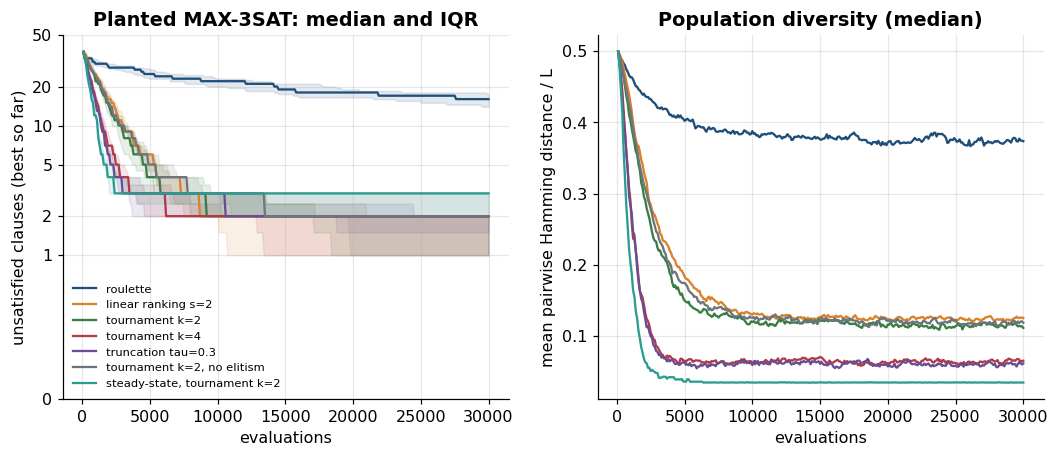

In [15]:
grid = np.arange(100, B + 1, 100)
from utils import best_so_far_on_grid
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
show = ["roulette", "linear ranking s=2", "tournament k=2", "tournament k=4", "truncation tau=0.3",
        "tournament k=2, no elitism", "steady-state, tournament k=2"]
for name, col in zip(show, list(PALETTE.values())):
    rr = runs[name]
    # after a run solves the instance its best-so-far stays at m, i.e. 0 unsatisfied clauses
    U = np.array([m_cl - np.r_[best_so_far_on_grid(r[0], r[1], grid[grid <= r[0][-1]]),
                               np.full((grid > r[0][-1]).sum(), r[1][-1])] for r in rr])
    Dv = np.array([np.r_[best_so_far_on_grid(r[0], r[2], grid[grid <= r[0][-1]]),
                         np.full((grid > r[0][-1]).sum(), np.nan)] for r in rr])
    med = np.median(U, 0)
    ax[0].plot(grid, med, color=col, label=name)
    ax[0].fill_between(grid, *np.percentile(U, [25, 75], axis=0), color=col, alpha=0.12)
    ax[1].plot(grid, np.nanmedian(Dv, 0), color=col, label=name)
ax[0].set_yscale("symlog", linthresh=1.0)
ax[0].set_yticks([0, 1, 2, 5, 10, 20, 50], ["0", "1", "2", "5", "10", "20", "50"])
ax[0].set(xlabel="evaluations", ylabel="unsatisfied clauses (best so far)",
          title="Planted MAX-3SAT: median and IQR")
ax[1].set(xlabel="evaluations", ylabel="mean pairwise Hamming distance / L",
          title="Population diversity (median)")
ax[0].legend(fontsize=7.5)
savefig("w4_selection_in_ga.png"); plt.show()

The diversity panel shows the mechanism behind the table: the strong schemes (tournament $k=4$, truncation
$\tau = 0.3$) collapse the population to a normalised pairwise distance of about $0.06$ within a few thousand
evaluations — takeover time of order $\ln n / \ln k$ generations — and the steady-state GA goes further still
(about $0.04$); afterwards mostly mutation creates novelty. Binary tournament and linear ranking settle around
$0.12$. Roulette keeps diversity high (about $0.38$, versus $0.5$ for a random population) but makes little
progress. Good settings live in between. This is the **exploration–exploitation trade-off expressed as selection
pressure**, and it is the knob that parameter-control schemes (Week 6) adjust online.

**AI relevance.** The same operators appear verbatim in evolutionary hyperparameter optimisation and neural
architecture search: tournament selection is the parent-selection rule of regularised evolution (Real et al. 2019,
Lab), truncation selection drives population-based training (Jaderberg et al. 2017), and rank-based selection is
what makes these methods insensitive to the (arbitrary) scale of a validation metric.

## Key takeaways

- A GA is selection (fitness-dependent, direction) + variation (fitness-blind, novelty) + replacement; every design
  question about pressure and diversity is a question about these three maps.
- Selection operators can be compared on common, verifiable scales: selection probabilities by rank, selection
  intensity ($I_2 = 1/\sqrt\pi$ for binary tournament; $\varphi(z_\tau)/\tau$ for truncation), takeover time
  ($(\ln n + \ln\ln n)/\ln k$ for tournaments) and one-generation loss of diversity ($(1-e^{-2})/2$ for $k = 2$).
- SUS is the unbiased sampler with minimal spread; roulette's binomial noise makes the best individual easy to lose
  by drift.
- Proportional selection depends on the fitness *scale* and collapses when values are compressed; rank-based
  schemes are invariant to monotone transformations and are the default in modern practice.
- Elitism is cheap insurance for the best-so-far; steady-state replacement is a high-pressure alternative to
  generational replacement at the same evaluation budget.

## Exercises

1. ★ Show that linear ranking with parameter $s$ has selection intensity $(s-1)/\sqrt{\pi}$ on a normal
   population in the large-$n$ limit. (Hint: $E[Z\,\Phi(Z)] = 1/(2\sqrt\pi)$.)
2. ★ Prove that roulette-wheel selection is unbiased but that the probability of losing the best individual in one
   generation is $(1 - e_{\max}/n)^n$; evaluate it for $e_{\max} = 2$ and $n = 100$ and compare with SUS.
3. ★★ Derive the exact (finite-$n$) takeover-time distribution of 2-tournament as a Markov chain on the number of
   best copies $j \in \lbrace 0..n\rbrace$ with $\mathrm{Binomial}(n, 1-(1-j/n)^2)$ transitions; compute its mean
   for $n = 64$ and compare with the simulated medians above.
4. ★★ Implement *exponential ranking* ($p_r \propto c^{\,n-1-r}$) and find the $c$ that matches the selection
   intensity of 3-tournament for $n = 100$.
5. ★★ Replace uniform crossover by one-point crossover in the MAX-3SAT experiment. Does the ranking of selection
   schemes change? Relate your answer to the fact that the variable order in the clause list is random.
6. ★★★ Implement *sigma scaling* ($f' = \max(0, 1 + (f - \bar f)/(2\sigma_f))$, Forrest 1985) before roulette
   selection and show, both theoretically (constant selection intensity on a normal population) and empirically on
   planted MAX-3SAT, that it repairs the failure of proportional selection.